# Part 3 — Geometry-based spatial graph construction

## Aim of Part 3

- Part 1 treated the fibre as a simple line of nuclei. 
- Part 2 replaced manual neighbour mixing with a graph Laplacian diffusion operator.
- Part 3 asks a more biological modelling question:

> If nuclei are not perfectly evenly spaced, how should spatial arrangement affect signal transport and rescue?

The main change is that the graph is no longer hard-coded as a line. Instead, nuclear positions are generated first, and the adjacency matrix is built from spatial proximity.


## Intuition from previous parts

Part 1 established the basic mechanism:

- corrected nuclei act as signal sources
- signal spreads locally
- rescue occurs when signal exceeds a threshold

Part 2 formalised the spreading mechanism using the graph Laplacian:

$$
L = D - A
$$

where:

- $A$ is the adjacency matrix
- $D$ is the degree matrix
- $L$ controls how signal diffuses across connected nodes

Part 3 keeps this operator but improves how $A$ is constructed.

Instead of assuming that node $i$ only connects to node $i-1$ and node $i+1$, this part asks:

> Which nuclei are close enough to exchange signal?

## Why?

The line graph from Part 2 is useful for learning, but it assumes perfectly regular spacing.

That is unlikely to reflect real muscle fibres, where nuclei may be unevenly distributed along the fibre. If spatial proximity matters, then two modelling decisions become important:

1. **Where are the nuclei located?**
2. **Which nuclei are close enough to interact?**

A geometry-based graph answers both.

The modelling chain becomes:

`nuclear positions → adjacency matrix → Laplacian → diffusion simulation → rescue outcome`


In [10]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1 — Generate nuclear positions

For this proof-of-concept, nuclei are represented as points along a 1D fibre.

To avoid assuming that all nuclei are evenly spaced, I generate slightly irregular spacing. This keeps the model simple while introducing a more realistic source of spatial heterogeneity.

The parameter `jitter` controls how much the nuclei deviate from perfectly even positions.

In [11]:
def generate_irregular_positions(n_nodes=30, fibre_length=1.0, jitter=0.015, seed=7):
    """Generate slightly irregular 1D nuclear positions along a fibre.

    The positions are sorted so that each nucleus still has a clear spatial order.
    This is a simple geometry model rather than a claim about exact biological spacing.
    """
    rng = np.random.default_rng(seed)
    base = np.linspace(0.0, fibre_length, n_nodes)
    noise = rng.normal(0.0, jitter, size=n_nodes)
    positions = np.clip(base + noise, 0.0, fibre_length)
    positions.sort()
    return positions


positions = generate_irregular_positions()
positions

array([1.84523004e-05, 3.89639417e-02, 6.48534494e-02, 9.00893983e-02,
       1.31110973e-01, 1.57539095e-01, 2.07798706e-01, 2.61482539e-01,
       2.68478971e-01, 3.01037704e-01, 3.52175217e-01, 3.84663650e-01,
       4.15374317e-01, 4.34318841e-01, 4.82319843e-01, 5.27670927e-01,
       5.31560920e-01, 5.79342660e-01, 5.92171314e-01, 6.35829348e-01,
       6.62029147e-01, 7.20611564e-01, 7.39608992e-01, 7.97172414e-01,
       8.29937473e-01, 8.58800328e-01, 8.59265001e-01, 9.22954089e-01,
       9.64789727e-01, 1.00000000e+00])

## Step 2 — Build adjacency from distance

Two nuclei are connected if their spatial distance is less than or equal to an interaction radius.

This encodes the assumption:

> local signal exchange is possible only between sufficiently nearby nuclei

**N.B:** This is still a simplified assumption.

In [12]:
def radius_adjacency(positions, interaction_radius=0.08):
    """Create an unweighted adjacency matrix from 1D spatial positions.

    A[i, j] = 1 when nuclei i and j are within the interaction radius.
    The diagonal remains zero because a nucleus is not treated as its own neighbour.
    """
    positions = np.asarray(positions)
    distances = np.abs(positions[:, None] - positions[None, :])
    A = (distances <= interaction_radius).astype(float)
    np.fill_diagonal(A, 0.0)
    return A


A = radius_adjacency(positions)
A

array([[0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 1

## Step 3 — Construct the graph Laplacian

The graph Laplacian is built as in Part 2:

$$
L = D - A
$$

- The difference is that $A$ now comes from geometry rather than from a fixed line rule.

- This means the same diffusion equation can operate on different spatial layouts without changing the simulation logic.


In [13]:
def graph_laplacian(A):
    """Return the combinatorial graph Laplacian L = D - A."""
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    return D - A


L = graph_laplacian(A)
L

array([[ 2., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [-1.,  3., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [-1., -1.,  4., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [ 0., -1., -1.,  4., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [ 0.,  0., -1., -1.,  4., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1., -1.,  3., -1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,

## Step 4 — Select corrected nuclei

Corrected nuclei are still represented as signal-producing source nodes.

For this part, I test a clustered correction pattern near the left side of the fibre. This is useful because it preserves continuity from previous sections, where the source region also began at the start of the line.

Later, this can be compared with distributed or random correction patterns.

In [14]:
def corrected_sources(n_nodes, corrected_fraction=0.1):
    """Return a boolean mask for corrected nuclei clustered at the start of the fibre."""
    n_corrected = max(1, round(n_nodes * corrected_fraction))
    corrected = np.zeros(n_nodes, dtype=bool)
    corrected[:n_corrected] = True
    return corrected


corrected = corrected_sources(len(positions), corrected_fraction=0.1)
corrected

array([ True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

## Step 5 — Simulate diffusion on the geometry-based graph

The update equation is:

$$
u_{t+1} = u_t + dt\left(-\alpha L u_t - \beta u_t + q\right)
$$

where:

- $\alpha$ controls transport strength
- $\beta$ controls signal decay
- $q$ is the production term from corrected nuclei
- $dt$ is the timestep

This is the same modelling idea as Part 2, but now the graph structure reflects spatial proximity.


In [15]:
def simulate_geometry_diffusion(
    positions,
    corrected_fraction=0.1,
    interaction_radius=0.08,
    alpha=0.25,
    beta=0.05,
    production_rate=0.08,
    threshold=1.0,
    dt=0.1,
    steps=200,
):
    """Simulate source-driven diffusion on a geometry-derived graph."""
    A = radius_adjacency(positions, interaction_radius=interaction_radius)
    L = graph_laplacian(A)

    n_nodes = len(positions)
    corrected = corrected_sources(n_nodes, corrected_fraction=corrected_fraction)

    signal = np.zeros(n_nodes)
    rescued = np.zeros(n_nodes, dtype=bool)
    q = np.zeros(n_nodes)
    q[corrected] = production_rate

    history = [signal.copy()]

    for _ in range(steps):
        signal = signal + dt * (-alpha * (L @ signal) - beta * signal + q)
        rescued |= signal > threshold
        history.append(signal.copy())

    return {
        "positions": positions,
        "adjacency": A,
        "laplacian": L,
        "signal": signal,
        "rescued": rescued,
        "corrected": corrected,
        "history": np.array(history),
    }


result = simulate_geometry_diffusion(positions)
result["signal"], result["rescued"]

(array([6.01442548e-01, 5.46674318e-01, 4.99102746e-01, 3.70400232e-01,
        2.98161214e-01, 2.50589642e-01, 1.68379234e-01, 9.37102732e-02,
        9.37102732e-02, 6.01756248e-02, 2.22521492e-02, 1.01939542e-02,
        9.04777888e-03, 6.13125447e-03, 3.72633513e-03, 1.31382148e-03,
        1.31382148e-03, 7.38395395e-04, 6.66929338e-04, 4.00537695e-04,
        2.39456817e-04, 8.20143564e-05, 8.20143564e-05, 3.04308739e-05,
        1.09789043e-05, 9.91043530e-06, 9.91043530e-06, 3.94683855e-06,
        1.35541118e-06, 1.35541118e-06]),
 array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]))

## Visualisation 1 — Spatial graph structure

This visualisation checks whether the adjacency rule produces a sensible interaction graph.

Each nucleus is plotted along the fibre. Lines indicate potential signal exchange between nearby nuclei.

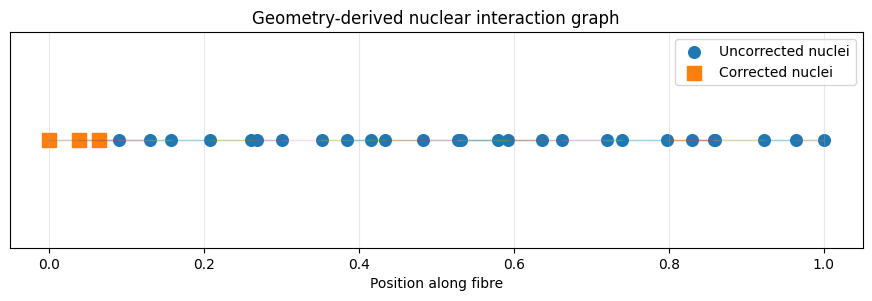

In [16]:
def plot_spatial_graph(result):
    positions = result["positions"]
    A = result["adjacency"]
    corrected = result["corrected"]

    plt.figure(figsize=(11, 2.8))

    for i in range(len(positions)):
        for j in range(i + 1, len(positions)):
            if A[i, j] > 0:
                plt.plot([positions[i], positions[j]], [0, 0], linewidth=1, alpha=0.25)

    plt.scatter(positions[~corrected], np.zeros((~corrected).sum()), s=70, label="Uncorrected nuclei")
    plt.scatter(positions[corrected], np.zeros(corrected.sum()), s=90, marker="s", label="Corrected nuclei")

    plt.yticks([])
    plt.xlabel("Position along fibre")
    plt.title("Geometry-derived nuclear interaction graph")
    plt.legend()
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()


plot_spatial_graph(result)

### Key insights from the spatial graph

- The graph is now based on physical distance along the fibre.
- Closely spaced nuclei can form denser local interaction regions, while wider gaps weaken spatial connectivity.
- Corrected nuclei remain clustered near the source boundary, preserving continuity with the earlier parts.
- This structure makes it possible to test how nuclear spacing affects signal reach and rescue.

## Visualisation 2 — Final signal profile over physical position

In Parts 1 and 2, signal was plotted against node index.

Signal is plotted against physical position. This matters because node index and spatial distance are no longer exactly the same once spacing becomes irregular.

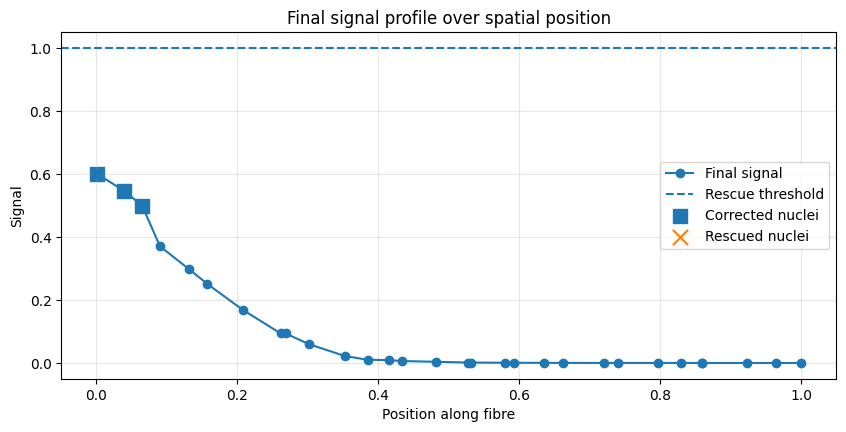

In [17]:
def plot_signal_by_position(result, threshold=1.0):
    positions = result["positions"]
    signal = result["signal"]
    corrected = result["corrected"]
    rescued = result["rescued"]

    plt.figure(figsize=(10, 4.5))
    plt.plot(positions, signal, marker="o", label="Final signal")
    plt.axhline(threshold, linestyle="--", label="Rescue threshold")

    plt.scatter(positions[corrected], signal[corrected], s=100, marker="s", label="Corrected nuclei")
    plt.scatter(positions[rescued], signal[rescued], s=120, marker="x", label="Rescued nuclei")

    plt.xlabel("Position along fibre")
    plt.ylabel("Signal")
    plt.title("Final signal profile over spatial position")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_signal_by_position(result)

### Key insights from the final signal profile

- Signal is still strongest near corrected nuclei, but the shape now depends on spatial connectivity rather than index alone.
- Irregular spacing changes the effective transport path because some nuclei are more strongly embedded in local neighbourhoods.
- Rescue remains threshold-dependent: receiving nonzero signal is not the same as becoming rescued.
- This visualisation makes the model more biologically interpretable because the x-axis now represents position along the fibre.

## Visualisation 3 — Signal propagation heatmap

The heatmap shows how signal evolves over time across nuclei.

The x-axis still uses nucleus index for readability, but the simulation itself is governed by the geometry-derived graph.

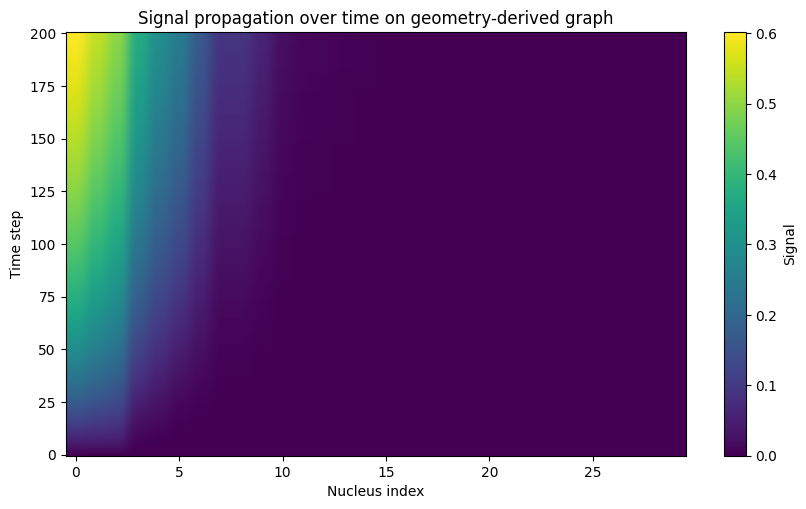

In [18]:
def plot_signal_heatmap(result):
    history = result["history"]

    plt.figure(figsize=(10, 5.5))
    plt.imshow(history, aspect="auto", origin="lower")
    plt.colorbar(label="Signal")
    plt.xlabel("Nucleus index")
    plt.ylabel("Time step")
    plt.title("Signal propagation over time on geometry-derived graph")
    plt.show()


plot_signal_heatmap(result)

### Key insights from the heatmap

- Signal still propagates outward from the corrected region, but the spread is mediated by the geometry-derived graph.
- Local dense regions can transmit signal more readily than sparse regions because they contain more graph edges.
- The signal approaches a stable spatial pattern rather than growing without bound.
- This confirms that the Part 2 Laplacian diffusion update remains stable after replacing the fixed line graph with a spatial graph.

## Interpretation of Part 3

Part 3 does not replace the Laplacian framework from Part 2. It improves the biological realism of the graph used by the Laplacian.

The key modelling shift is:

`fixed line graph → geometry-derived spatial graph`


## Part 3 Summary

- A separation between nuclear geometry and signal transport
- A distance-based rule for constructing adjacency matrices
- A reusable Laplacian diffusion simulator for irregular spatial layouts
- Visual checks for graph structure, signal profile, and signal dynamics
- A clearer link between biological spacing assumptions and numerical outcomes
